In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from gurobipy import *
import gurobipy as gp
from gurobipy import GRB
sns.set(style ="whitegrid", font_scale=1.5)
from matplotlib.ticker import MultipleLocator
import matplotlib
from matplotlib.colors import LinearSegmentedColormap
custom_colors = ["#c45161", "#e094a0", "#f2b6c0", "#f2dde1", "#cbc7d8", "#8db7d2", "#5e62a9", "#434279"]
cmap = LinearSegmentedColormap.from_list("custom_cmap", custom_colors)
color_palette = np.array(["#c45161", "#e094a0", "#f2b6c0", "#f2dde1", "#cbc7d8", "#8db7d2", "#5e62a9", "#434279"])
color = ['#93003a', '#00429d', '#93c4d2', '#6ebf7c']
matplotlib.rcParams.update({'legend.fontsize': 14, 'legend.handlelength': 2})
from tqdm import tqdm
import sys
import os
import pickle
parent_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
sys.path.append(parent_dir)
import importlib
import re
from geopy.distance import geodesic

### Prepare input

#### Load `uam_system_model` dependencies

In [4]:
from uam_system_model.StarNetwork import StarNetwork
from uam_system_model.utils.visualize import plot_parameters, plot_travel_time

#### Prepare input

In [5]:
def calculate_distances_in_meters(coords):
    num_points = len(coords)
    distance_matrix = np.zeros((num_points, num_points))
    for i in range(num_points):
        for j in range(num_points):
            if i != j:
                distance_matrix[i][j] = geodesic(coords[i], coords[j]).meters / 1600
    return distance_matrix

coordinates = np.array(
    [
        (33.94417072663332, -118.40248449470265),
        (34.043119432990345, -118.26720629762752),
        (33.81606030845284, -118.15122129260827),
        (34.17160155814583, -118.60525790222589),
        (34.13843197335217, -118.35511311047983),
        (33.812102161009804, -117.91897753216998),
        (34.09174681098575, -118.32725521957076),
        (34.08807589928915, -118.55063573741867),
        (34.06666969690935, -118.4114352069469),
    ]
)

distance_matrix = calculate_distances_in_meters(coordinates)
vertiports = ["LAX", "DTLA", "LGB", "WDHL", "UVS", "ANH", "HWD", "PSD", "BVH"]

vertiport_pmf = np.array([0, 6.1, 3.3, 1.5, 1.5, 5.4, 4.3, 2.5, 2.2])

# vertiport_pmf = np.array([0, 3.8, 2.4, 1, 1, 4.1, 2.5, 2.2, 1.5])

vertiport_pmf = vertiport_pmf / vertiport_pmf.sum()

flight_time_matrix = np.load("../UAM-System-Model/uam_system_model/data/config/flight_time_matrix.npy")
energy_consumption_matrix = np.load(
    "../UAM-System-Model/uam_system_model/data/config/energy_consumption_matrix.npy"
)

#### Create instance variable

In [6]:
network = StarNetwork(
    vertiport_names=vertiports,
    flight_distance_matrix=distance_matrix,
    flight_time_matrix=flight_time_matrix,
    energy_consumption_matrix=energy_consumption_matrix,
)

#### Load demand

In [7]:
SURVEY_P_TNC = 0.33327  # from the recorded data

total_seat = network.demand_generator.yearly_capacity[0] + network.demand_generator.yearly_capacity[1]
OD_PAX_TO_SEAT_RATIO = 77500000 / total_seat # from the recorded data

VERTIPORT_PMF = np.array([0, 3.8, 2.4, 1, 1, 4.1, 2.5, 2.2, 1.5])/ 100 # from passenger origin survey data

vertiport_density = np.zeros((len(VERTIPORT_PMF), len(VERTIPORT_PMF)))
vertiport_density[0, :] = VERTIPORT_PMF
vertiport_density[:, 0] = VERTIPORT_PMF

p_uam_array = 1 * SURVEY_P_TNC * OD_PAX_TO_SEAT_RATIO
p_uam_array = p_uam_array * (np.repeat(vertiport_density[:, :, np.newaxis], 24, axis=2))

p_uam_array = np.concatenate([[p_uam_array[0,:,:] , p_uam_array[:,0,:]]])
network.load_demand(
    month=9,
    day=5,
    vertiport_pmf=p_uam_array,
    max_waiting_time=10,
    auto_regressive_alpha=0.7,
    seed=9,
)

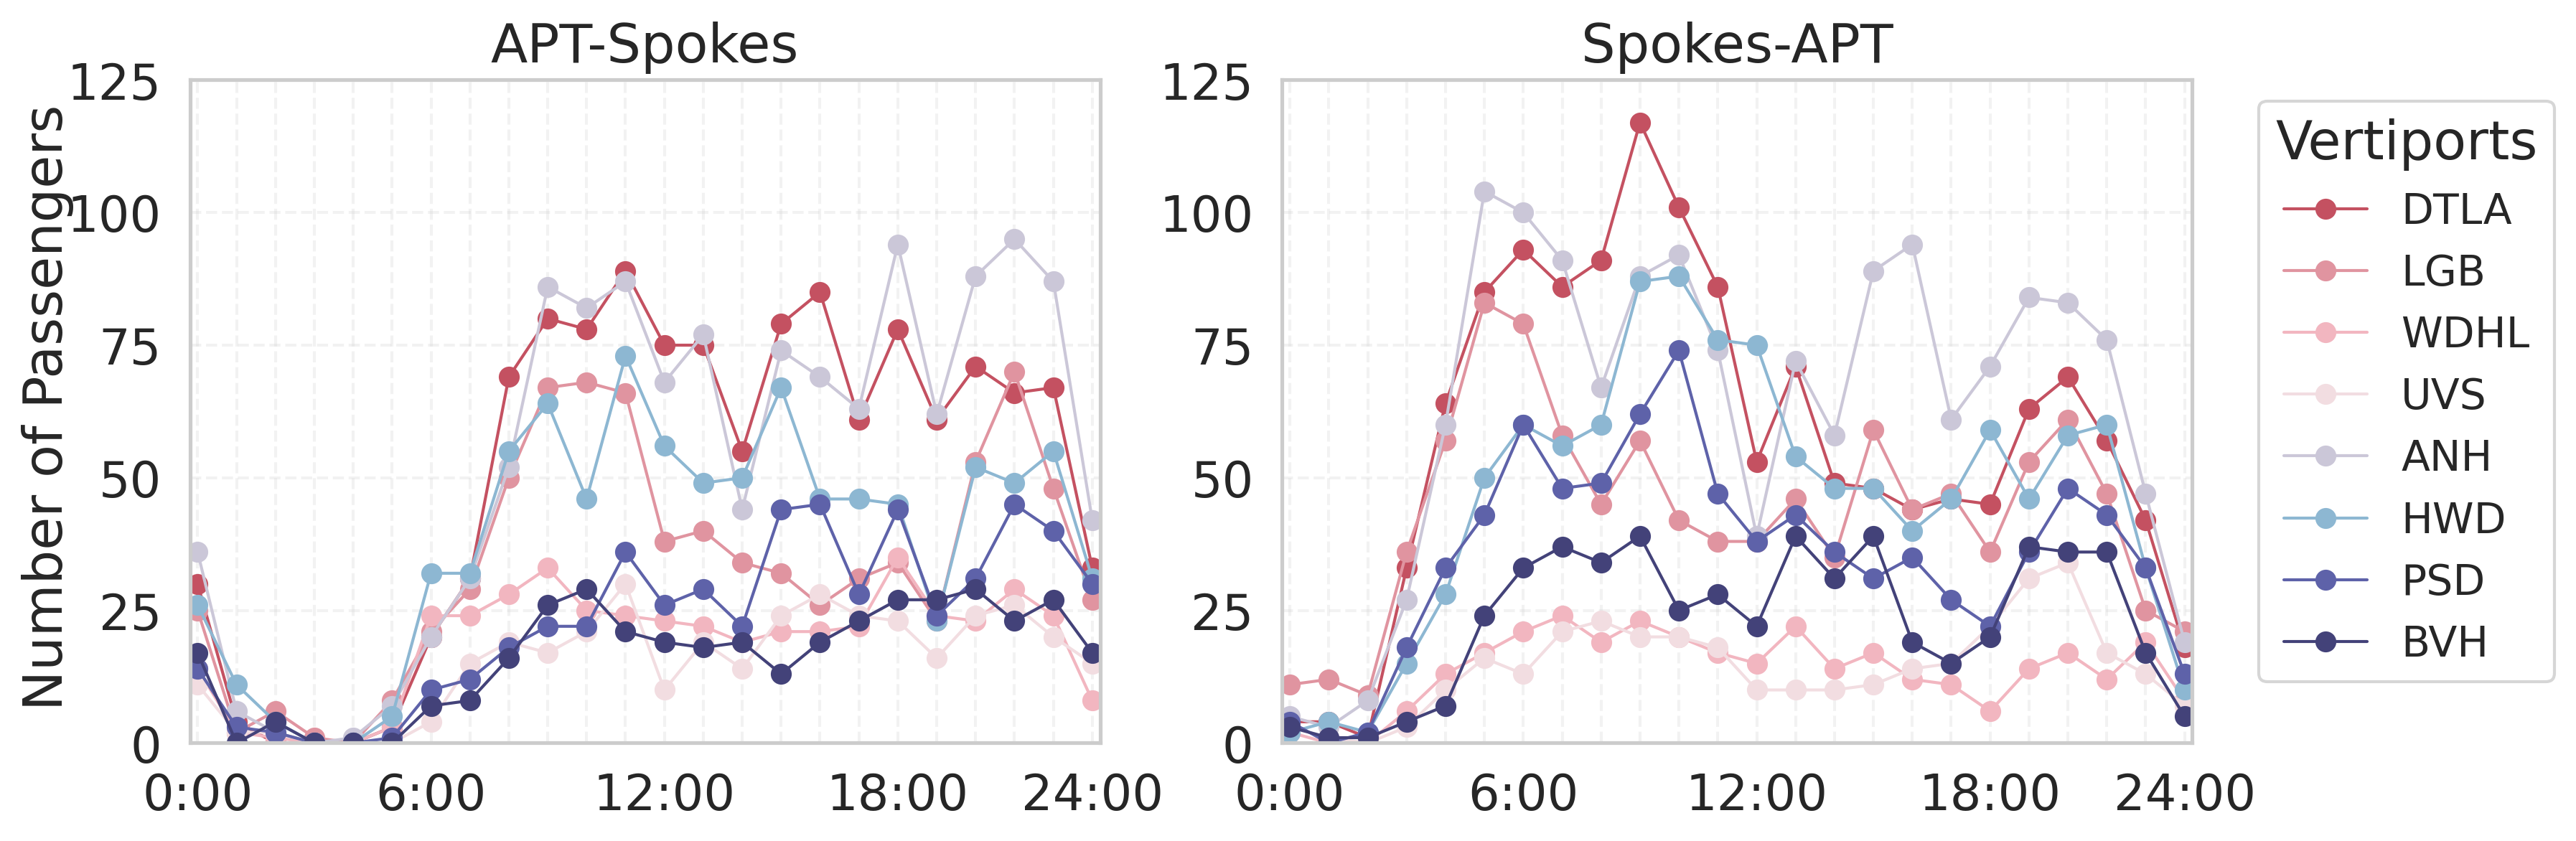

In [8]:
network.plot_pax(ylim=(0, 125));

### Pricing problem

In [9]:
import uam_system_model.Pricing
importlib.reload(uam_system_model.Pricing)
from uam_system_model.Pricing import PricingOptimizer
import uam_system_model.utils.PricingOpSummary
importlib.reload(uam_system_model.utils.PricingOpSummary)
from uam_system_model.utils.PricingOpSummary import PricingOpSummary

In [135]:
op = PricingOptimizer(StarNetwork=network)
with open("config/travel_time.pkl", "rb") as file:
     uber_travel_time, first_mile, last_mile, distance_avg = pickle.load(file)
    
first_or_last_distance = np.zeros(shape=(9,9,24))
first_or_last_distance[0,:,:] = distance_avg
first_or_last_distance[:,0,:] = distance_avg
uam_flight_time = np.load("../UAM-System-Model/uam_system_model/data/config/flight_time_matrix.npy") * 5

# df = op.optimize(time_resolution=30, 
#                     num_vehicles=25, 
#                     uber_travel_time=uber_travel_time, 
#                     first_mile_time=first_mile, 
#                     last_mile_time=last_mile, 
#                     first_or_last_distance=first_or_last_distance,
#                     uam_flight_time=uam_flight_time, 
#                     uam_distance_matrix=distance_matrix,
#                     optimality_gap=0.05,
#                )


In [69]:
df = pd.read_csv("pricing_output/pricing_vot_substitution.csv")
pricingSummary = PricingOpSummary(network, df)

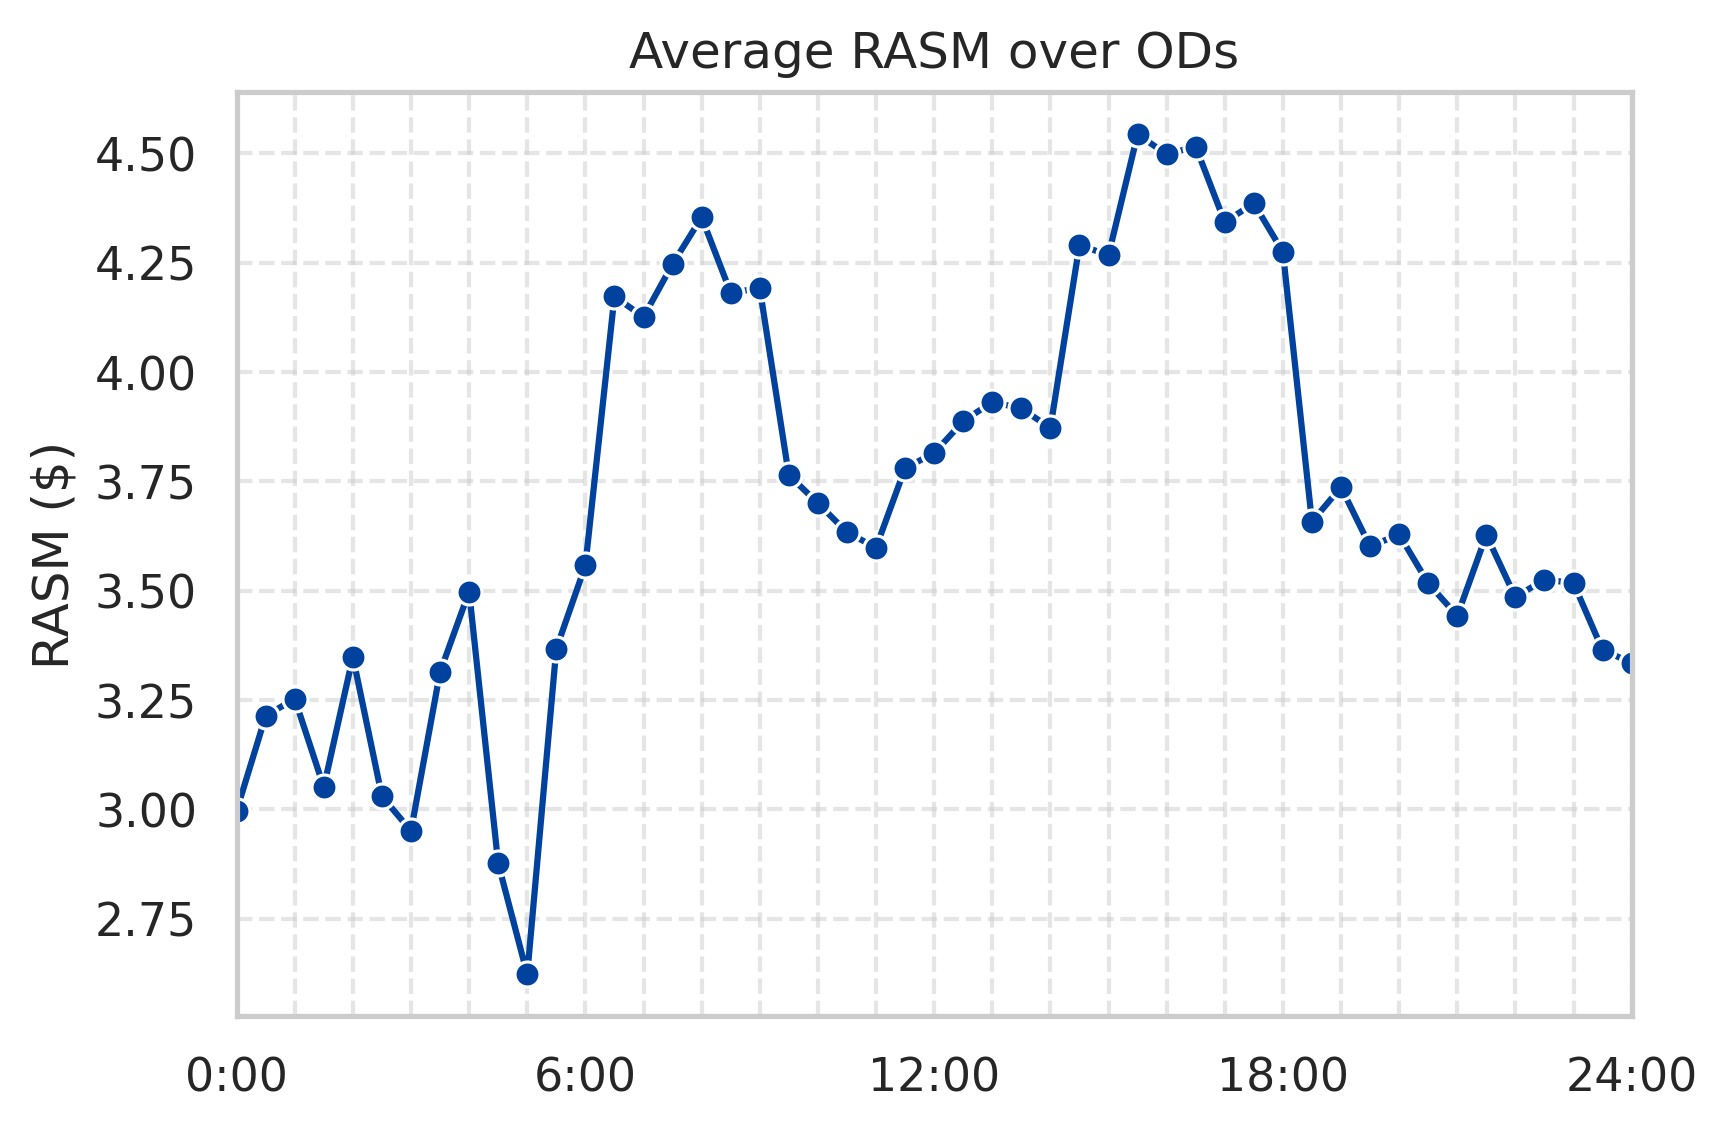

In [137]:
pricingSummary.plot_average_rasm(dpi=300);

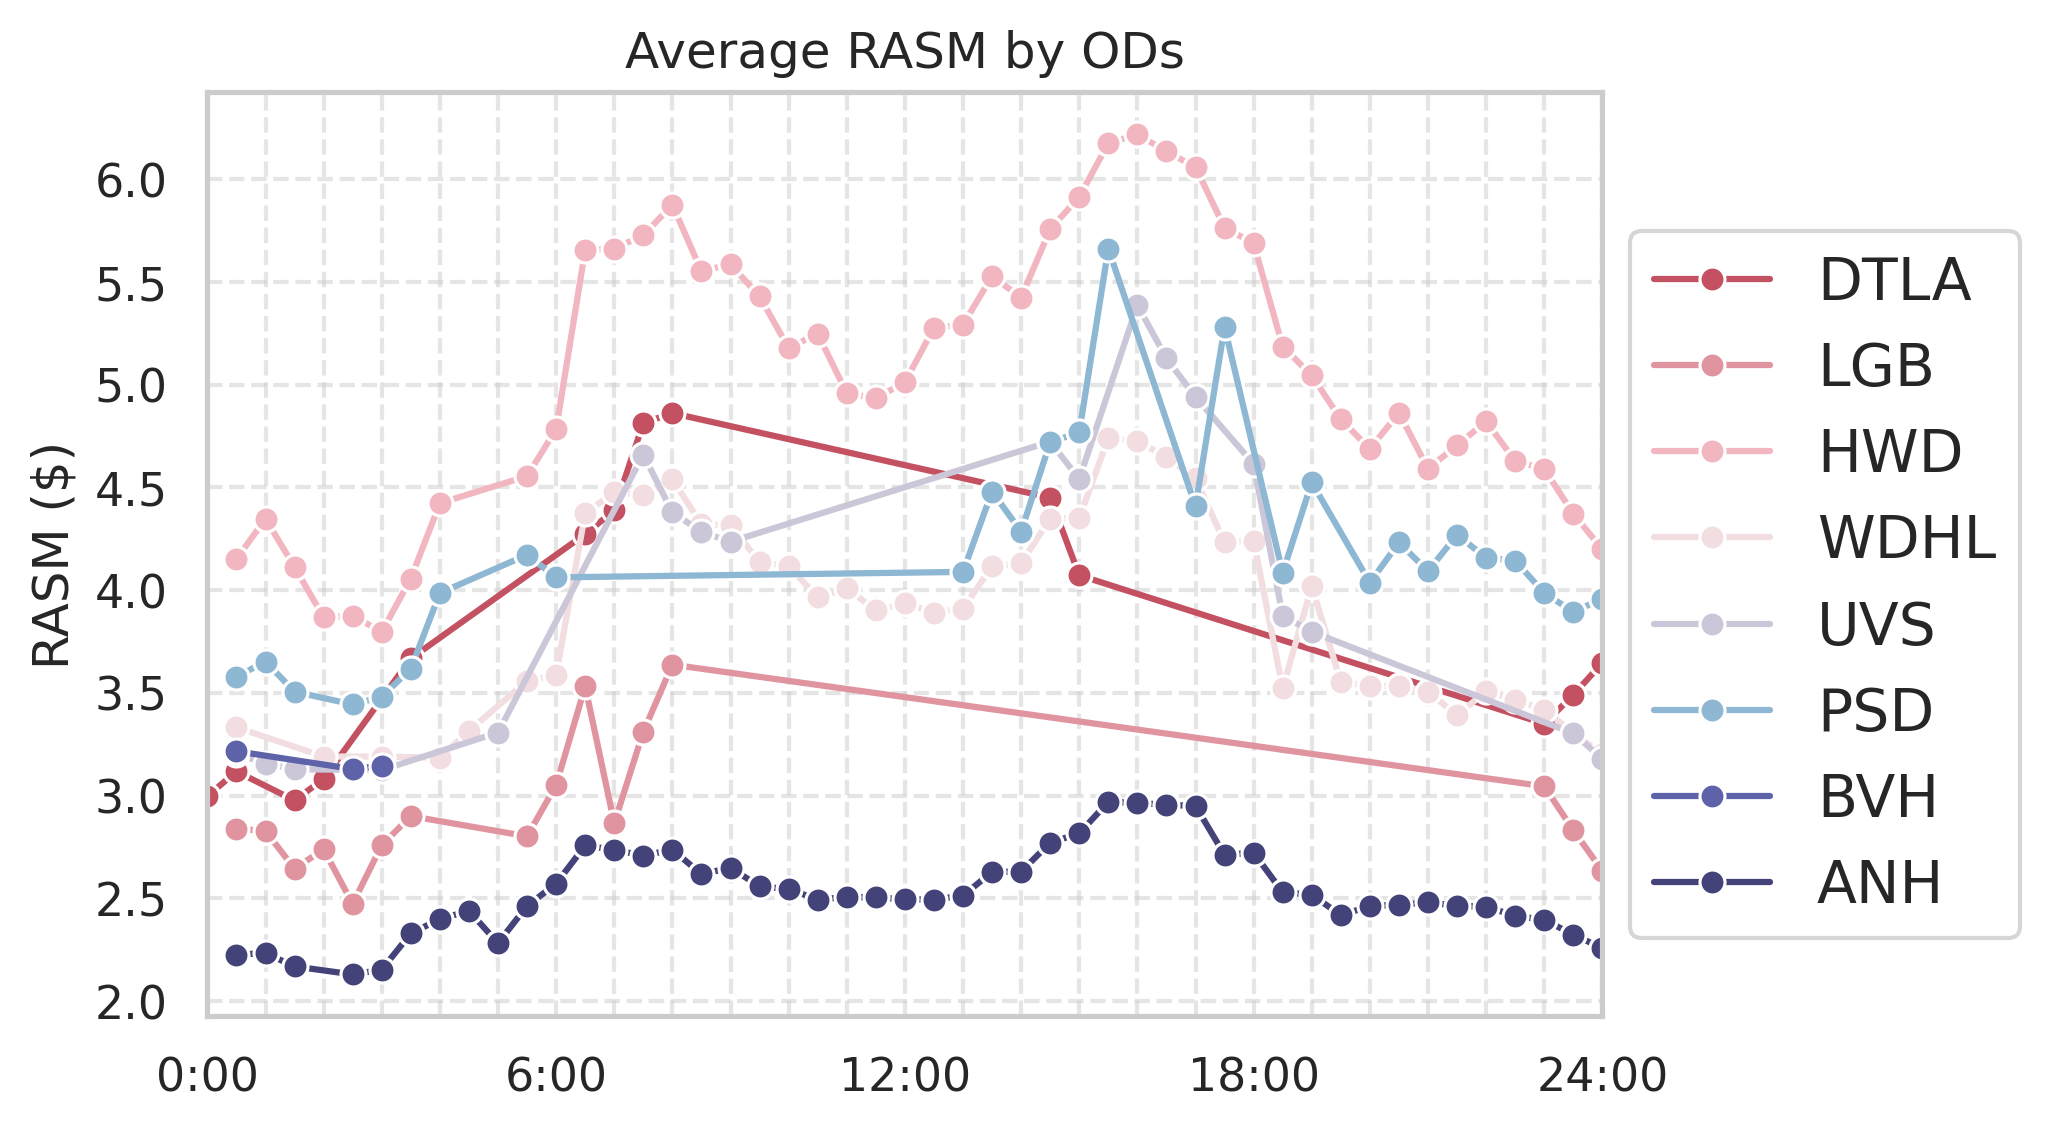

In [138]:
pricingSummary.plot_rasm_by_od(dpi=300);

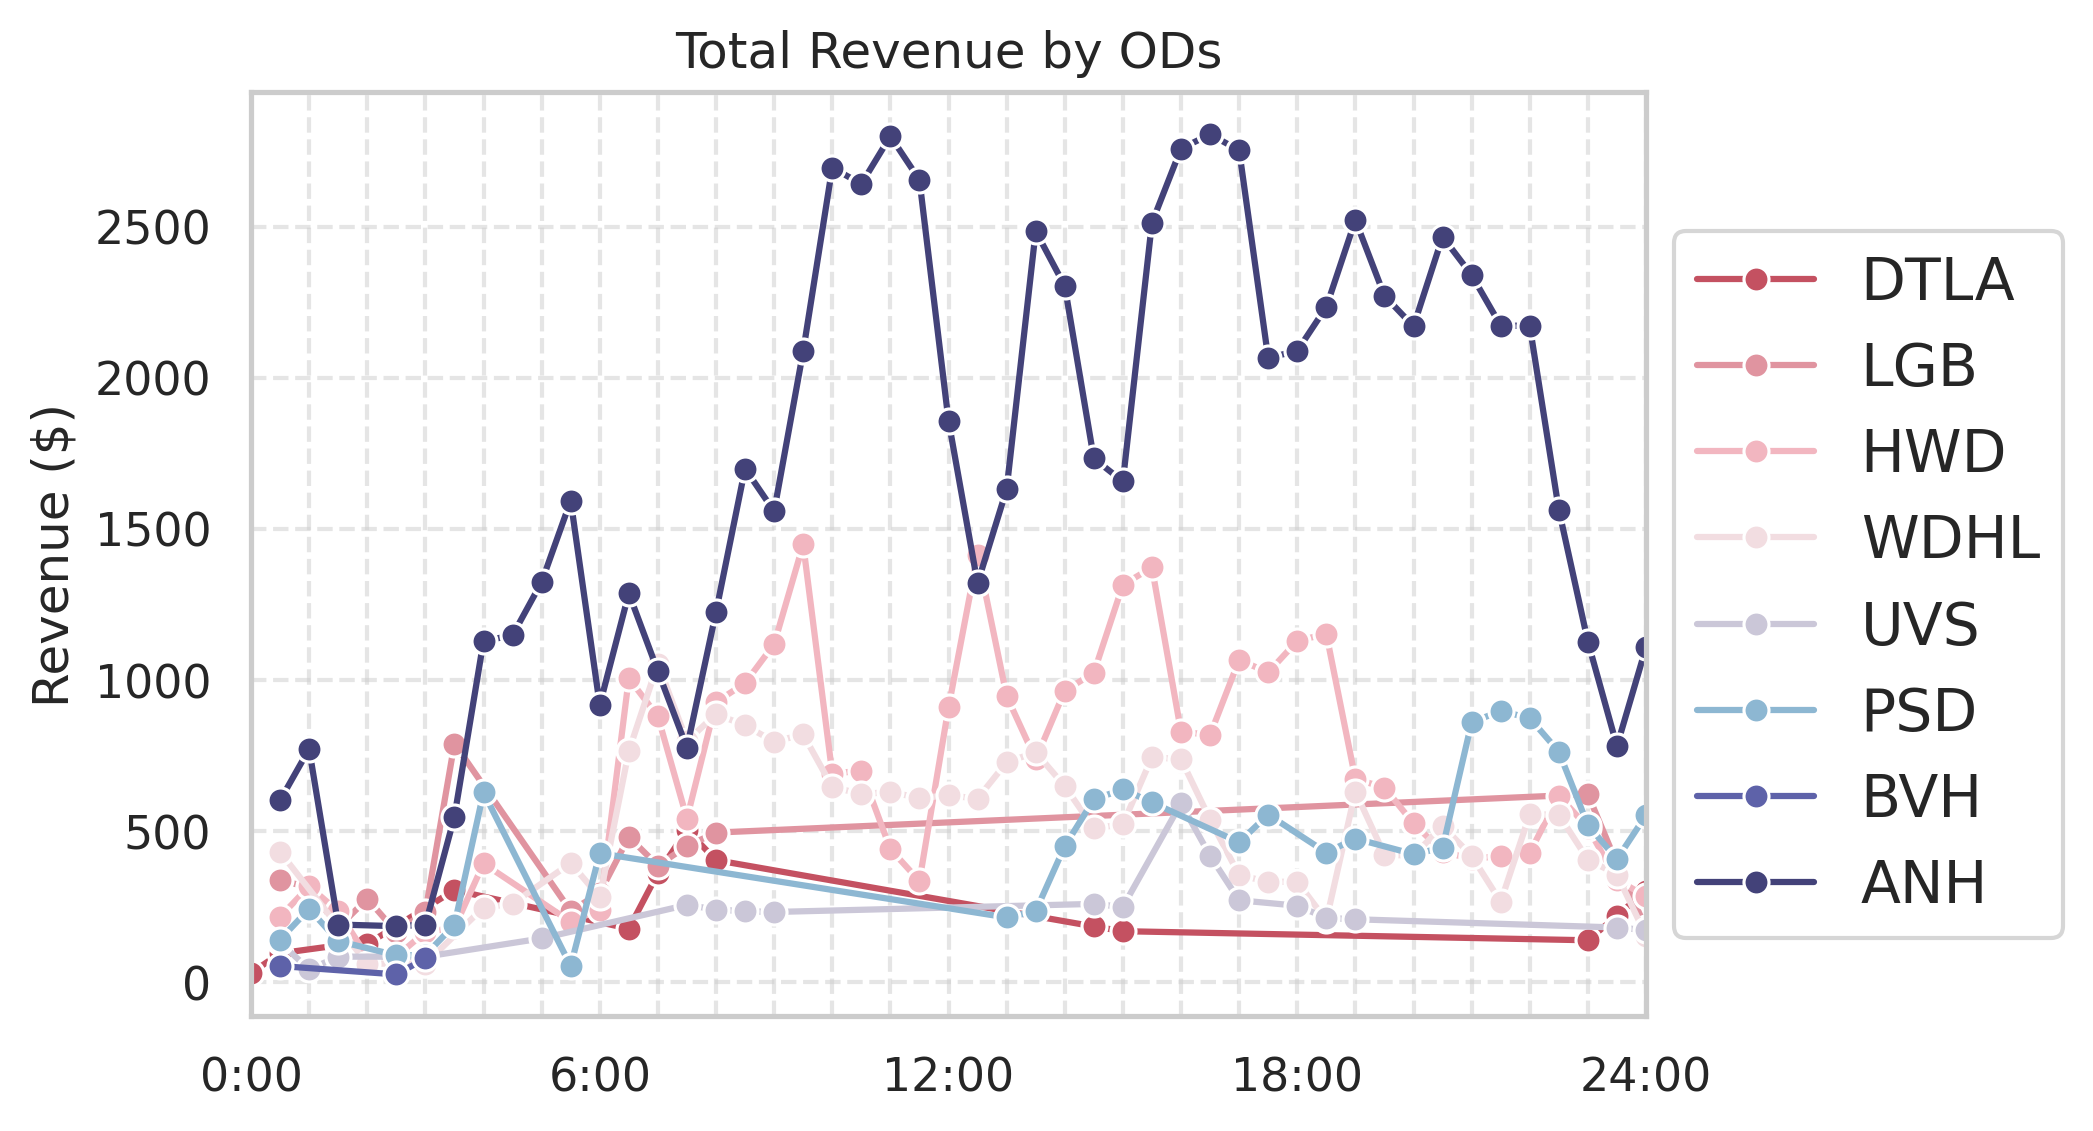

In [139]:
pricingSummary.plot_revenue_by_od(dpi=300);

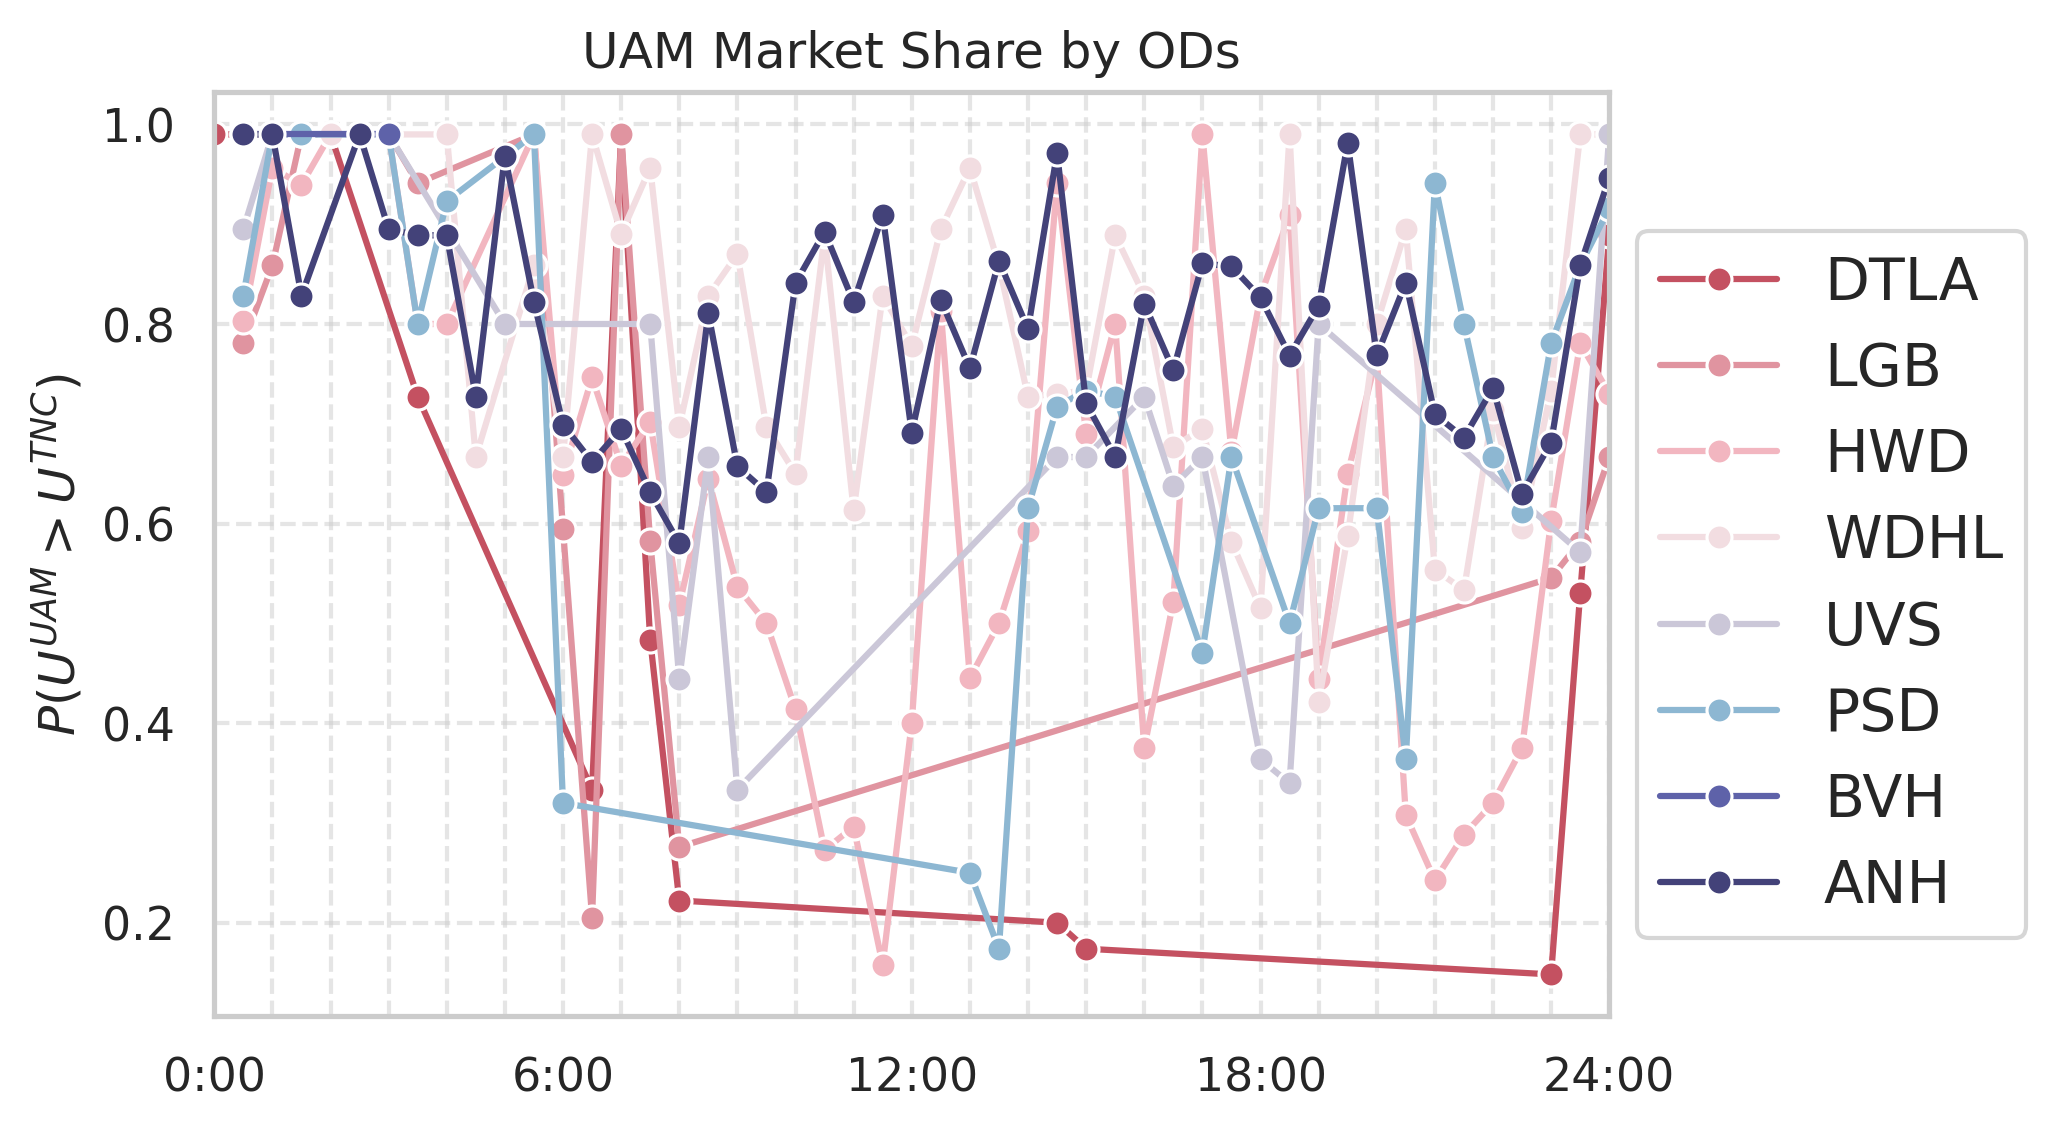

In [42]:
fig, ax = pricingSummary.plot_uam_share_by_od(dpi=300);

#### Get input to routing

In [70]:
df['hour'] = df['passenger_arrival_time_slot'] // 2
df.loc[df['hour'] == 24, 'hour'] = 23

input_to_routing = df.groupby(['hour', 'origin_vertiport_id', 'destination_vertiport_id'])[['fare', 'percentage_uam']].mean().reset_index()
input_to_routing['origin_vertiport_id'] = input_to_routing['origin_vertiport_id']
input_to_routing['destination_vertiport_id'] = input_to_routing['destination_vertiport_id']

In [71]:
def calc_share(uber_travel_time, uam_travel_time, uber_cost, uam_cost, value_of_time=32.63/60):
    v_uam = 1/value_of_time * uam_cost + uam_travel_time
    v_uber = 1/value_of_time * uber_cost + uber_travel_time
    p_uam = np.exp(v_uam) / (np.exp(v_uber)
        + np.exp(v_uam))
    print("v_uber:", v_uber, "v_uam:", v_uam)
    return p_uam


def calc_fare(uber_travel_time, uam_travel_time, uber_cost, uam_cost):
    beta_trip_time = -0.0192
    beta_trip_cost = -0.0353
    v_uber = beta_trip_time * uber_travel_time + beta_trip_cost * uber_cost
    v_uam = beta_trip_time * uam_travel_time + beta_trip_cost * uam_cost
    p_uam = np.exp(v_uam) / (np.exp(v_uber)
        + np.exp(v_uam))
    print("v_uber:", v_uber, "v_uam:", v_uam)
    return p_uam


#### Create instance variable

In [72]:
network = StarNetwork(
    vertiport_names=vertiports,
    flight_distance_matrix=distance_matrix,
    flight_time_matrix=flight_time_matrix,
    energy_consumption_matrix=energy_consumption_matrix,
)

#### Load demand & visualize

In [73]:
p_uam_array = np.zeros((len(vertiports), len(vertiports), 24))
for index, row in input_to_routing.iterrows():
    origin_idx = int(row['origin_vertiport_id'])
    dest_idx = int(row['destination_vertiport_id']) 
    hour = int(row['hour'])
    # if hour < 24:
    p_uam_array[origin_idx, dest_idx, hour] = row['percentage_uam']

SURVEY_P_TNC = 0.33327  # from the recorded data

total_seat = network.demand_generator.yearly_capacity[0] + network.demand_generator.yearly_capacity[1]
OD_PAX_TO_SEAT_RATIO = 77500000 / total_seat # from the recorded data

VERTIPORT_PMF = np.array([0, 3.8, 2.4, 1, 1, 4.1, 2.5, 2.2, 1.5])/ 100 # from passenger origin survey data

p_uam_array = p_uam_array * SURVEY_P_TNC * OD_PAX_TO_SEAT_RATIO

vertiport_density = np.zeros((len(VERTIPORT_PMF), len(VERTIPORT_PMF)))
vertiport_density[0, :] = VERTIPORT_PMF
vertiport_density[:, 0] = VERTIPORT_PMF
p_uam_array = p_uam_array * (np.repeat(vertiport_density[:, :, np.newaxis], 24, axis=2))

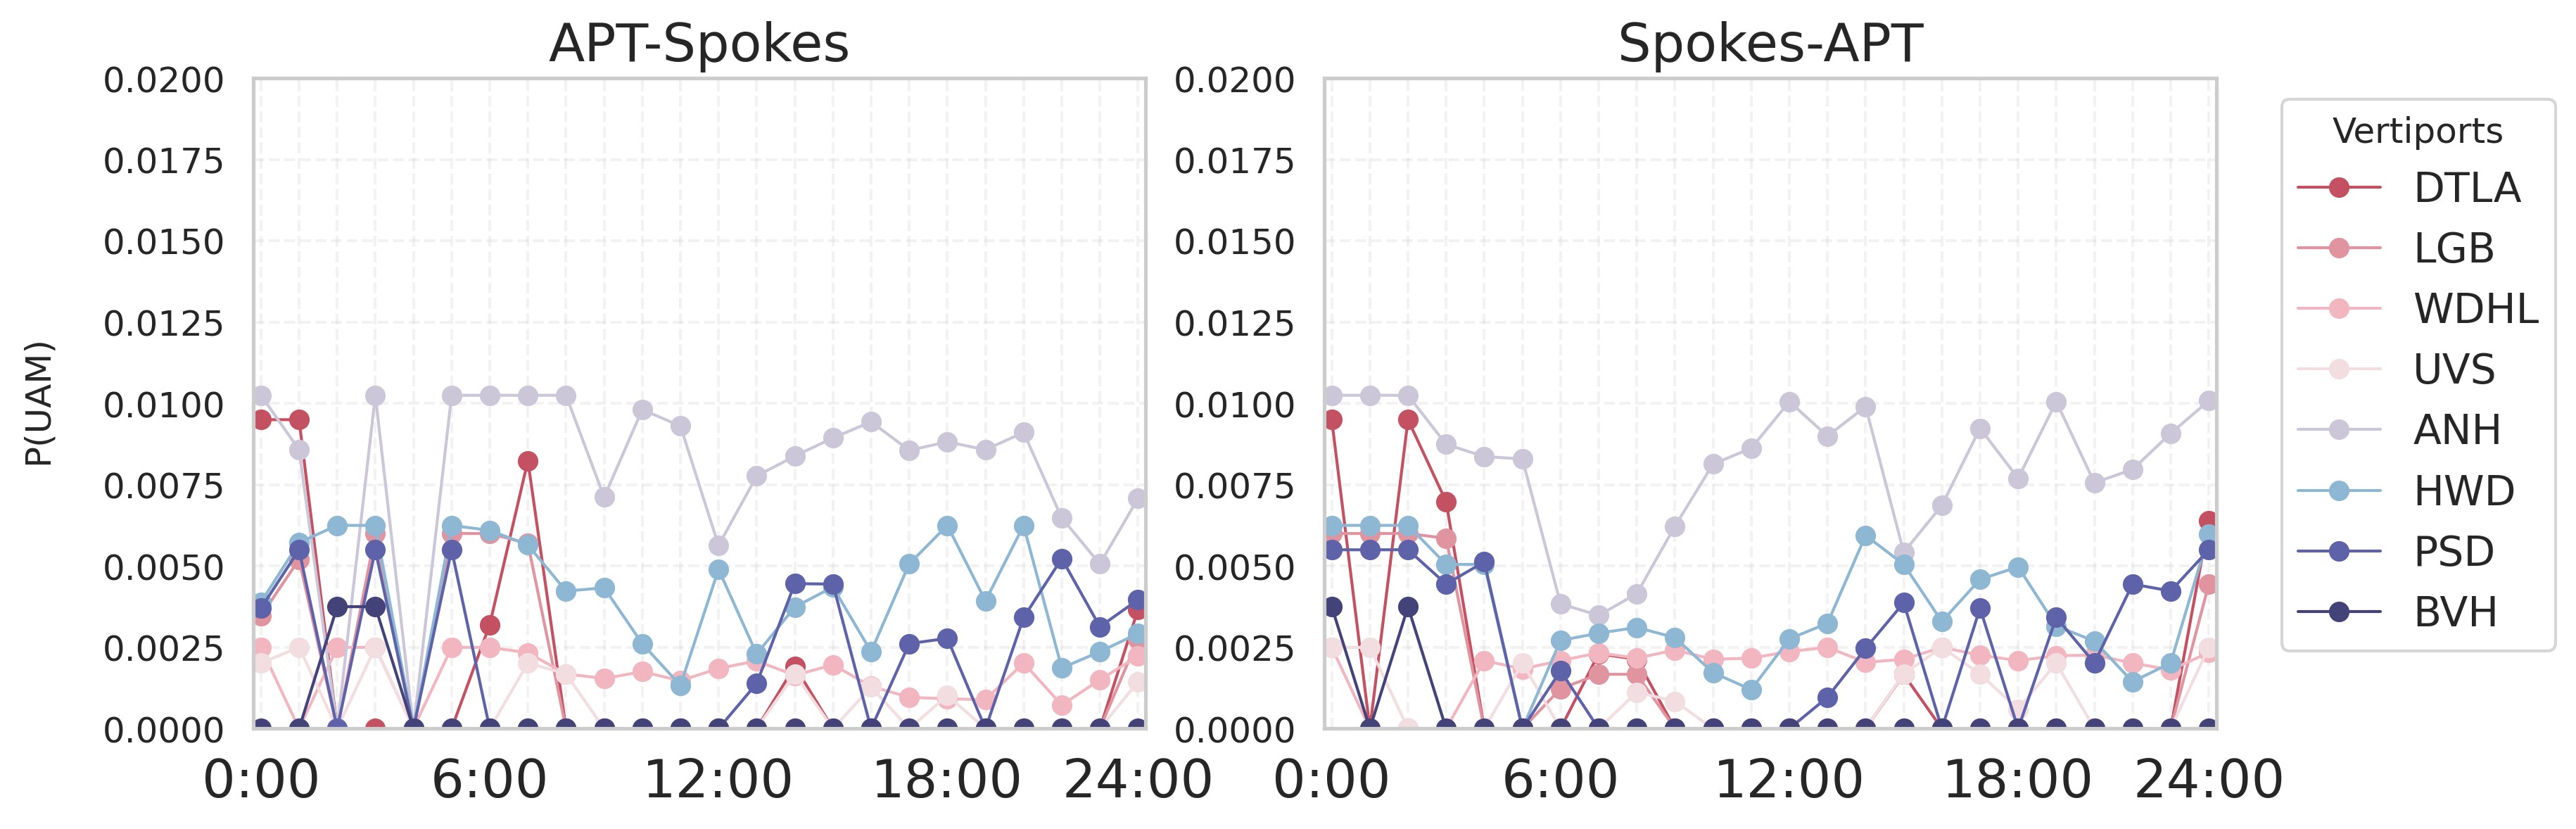

In [74]:
from uam_system_model.utils.visualize import plot_parameters, plot_travel_time

fig, ax = plot_travel_time(p_uam_array, vertiports, ylim=(0, 0.02), ylabel=r"")
for i in range(2):
    ax[i].tick_params(axis='y', labelsize=12)
fig.text(
    0.04, 0.5, "P(UAM)", ha="center", va="center", rotation="vertical"
);

In [75]:
p_uam_array = np.concatenate([[p_uam_array[0,:,:] , p_uam_array[:,0,:]]])

In [77]:
network.load_demand(
    month=9,
    day=5,
    vertiport_pmf=p_uam_array,
    max_waiting_time=10,
    auto_regressive_alpha=0.7,
    seed=9,
)

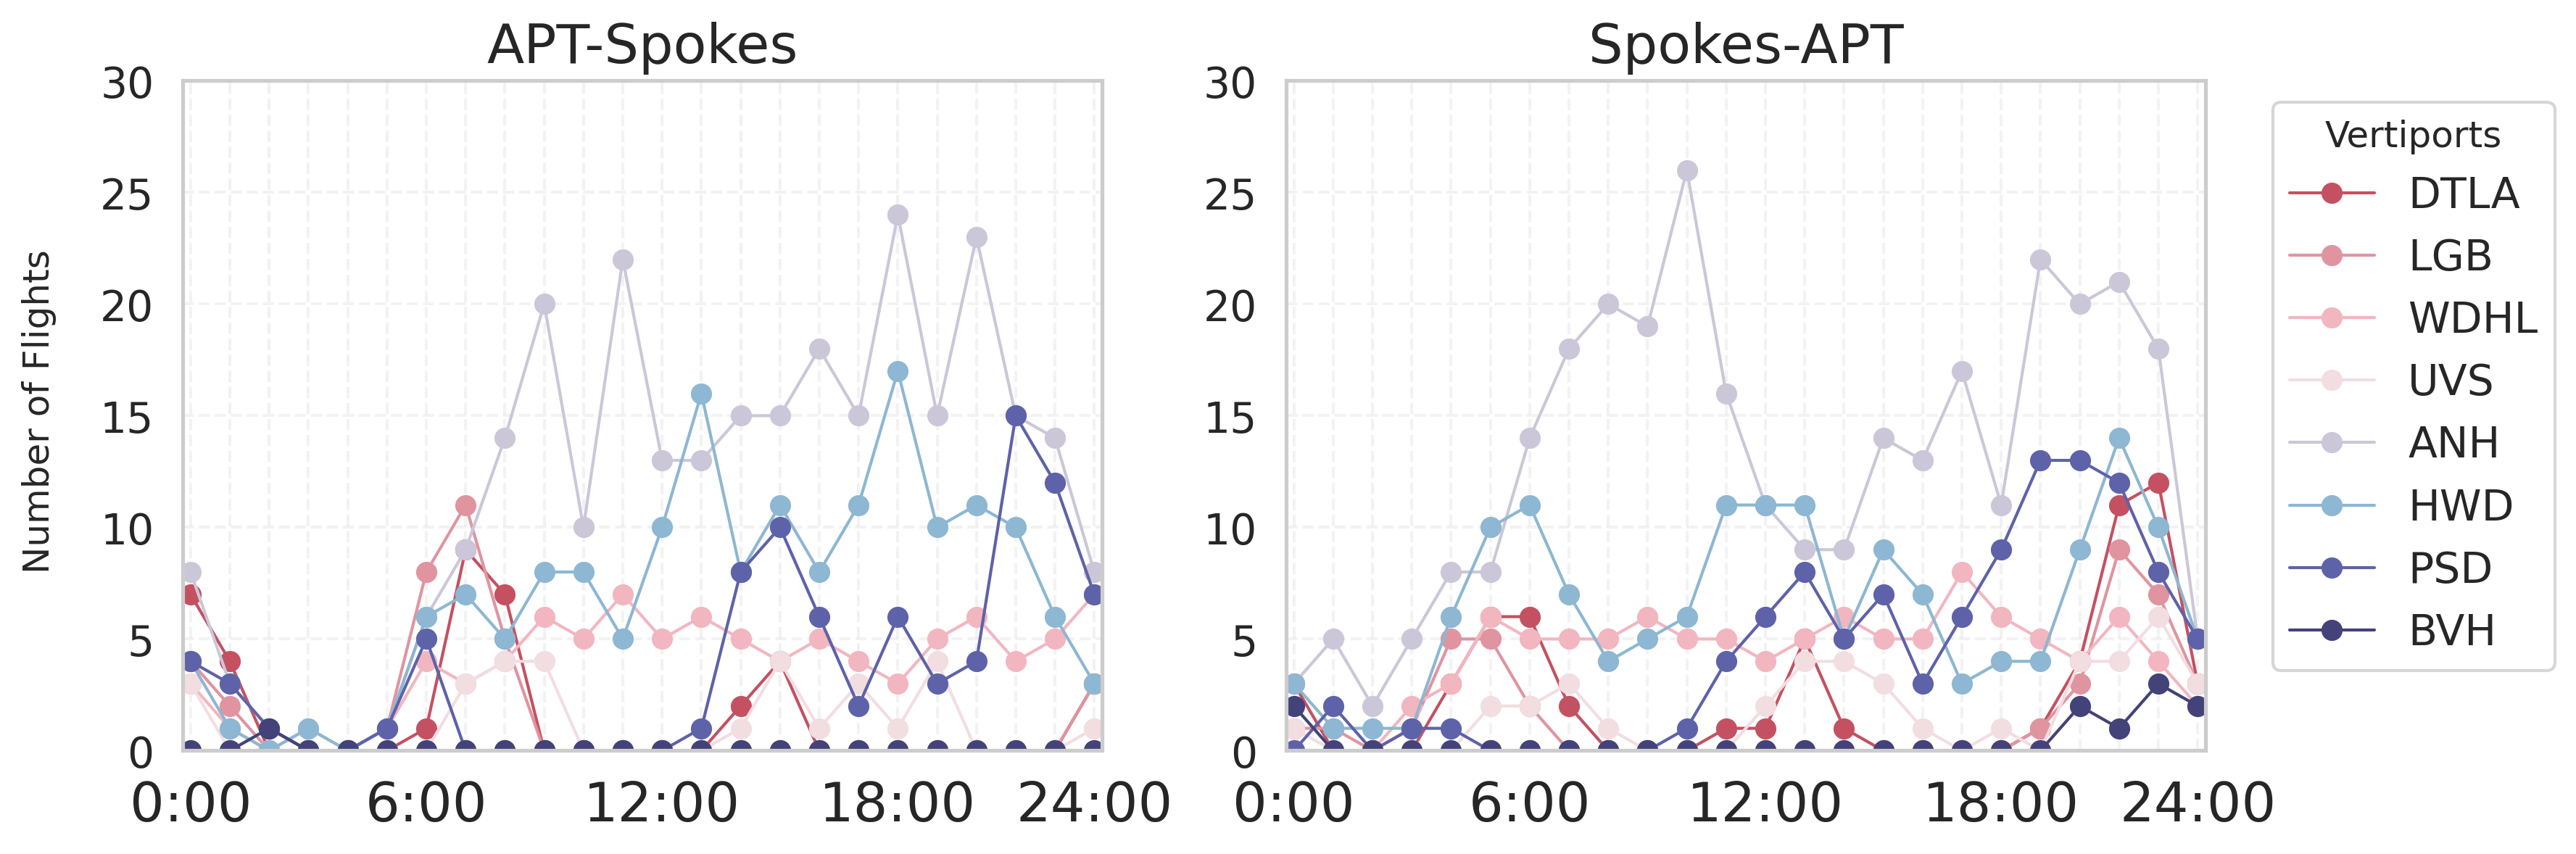

In [78]:
network.plot_flight(ylim=(0, 30));

In [25]:
print("potential revenue:", network.schedule['revenue'].sum())
print("num flights:", len(network.schedule))

potential revenue: 373023.72
num flights: 1558


In [26]:
schedule = network.schedule.copy()
schedule['hour'] = schedule['schedule'] // 60
input_to_routing['od'] = input_to_routing.apply(lambda row: f"{network.vertiport_dict_inv[row['origin_vertiport_id']]}_{network.vertiport_dict_inv[row['destination_vertiport_id']]}", axis=1)

new_schedule = pd.merge(schedule, input_to_routing, on=['hour', 'od'], how='left')
new_schedule['revenue'] = new_schedule['num_pax'] * new_schedule['fare']
new_schedule = new_schedule[['schedule', 'od', 'num_pax', 'revenue']]

def find_closest_fare(row, input_to_routing):
    if pd.isna(row['revenue']):
        origin = row['od'].split('_')[0]
        destination = row['od'].split('_')[1]
        hour = row['schedule'] // 30
        subset = input_to_routing[
            (input_to_routing['origin_vertiport_id'] == network.vertiport_dict[origin]) &
            (input_to_routing['destination_vertiport_id'] == network.vertiport_dict[destination])
        ]
        closest_hour = subset.iloc[(subset['hour'] - hour).abs().argsort()[:1]]
        return closest_hour['fare'].values[0] * row['num_pax']
    else:
        return row['revenue']

def find_closest_fare_uber(row):
    uber_fare = np.array([0, 50, 62, 78, 57, 77, 57, 57, 45])

    if pd.isna(row['revenue']):
        origin = row['od'].split('_')[0]
        destination = row['od'].split('_')[1]

        origin = network.vertiport_dict[origin]
        destination = network.vertiport_dict[destination]
        if origin == 0:
            return uber_fare[destination] * row['num_pax']
        if destination == 0:
            return uber_fare[origin] * row['num_pax']
    else:
        return round(row['revenue'],2)


new_schedule['revenue'] = new_schedule.apply(lambda row: find_closest_fare_uber(row), axis=1)


network.schedule = new_schedule.copy()

with open("config/network_class_routing_input_scale_1.pkl", "wb") as file:
    pickle.dump(network, file)

In [96]:
# with open("config/network_class_routing_input.pkl", "rb") as file:
#     network = pickle.load(file)

### Analytics

In [14]:
import uam_system_model.utils.FleetOpVRPSummary
importlib.reload(uam_system_model.utils.FleetOpVRPSummary)
from uam_system_model.utils.FleetOpVRPSummary import FleetOpVRPSummary

In [16]:
SURVEY_P_TNC = 0.33327  # from the recorded data

total_seat = network.demand_generator.yearly_capacity[0] + network.demand_generator.yearly_capacity[1]
OD_PAX_TO_SEAT_RATIO = 77500000 / total_seat # from the recorded data

VERTIPORT_PMF = np.array([0, 3.8, 2.4, 1, 1, 4.1, 2.5, 2.2, 1.5])/ 100 # from passenger origin survey data

p_uam_array = np.load("config/p_uam_array_10min_wait_deterministic.npy") * SURVEY_P_TNC * OD_PAX_TO_SEAT_RATIO

vertiport_density = np.zeros((len(VERTIPORT_PMF), len(VERTIPORT_PMF)))
vertiport_density[0, :] = VERTIPORT_PMF
vertiport_density[:, 0] = VERTIPORT_PMF
p_uam_array = p_uam_array * (np.repeat(vertiport_density[:, :, np.newaxis], 24, axis=2))

p_uam_array = np.concatenate([[p_uam_array[0,:,:] , p_uam_array[:,0,:]]])

network.load_demand(
    month=9,
    day=5,
    vertiport_pmf=p_uam_array,
    max_waiting_time=10,
    auto_regressive_alpha=0.7,
)

In [58]:
path = "output/pricing_output_scale_1/"
path = 'output/ECO_WAIT10_FARE3_NOV27/'
path = "output/pricing_output_scale_1/"
policy_0 = pd.read_csv(path + "25_4_4_4.csv")
summary_0 = FleetOpVRPSummary(network, policy_0)
statistics_0 = summary_0.get_summary_statistics()
df = pd.DataFrame([statistics_0])

required_pads = {}
for row in df['pads_at_vertiport']:
    for key, value in row.items():
        # Keep the max value seen so far for each key
        if key not in required_pads:
            required_pads[key] = value
        else:
            required_pads[key] = max(required_pads[key], value)
required_pads

{'LAX': 13,
 'DTLA': 6,
 'LGB': 3,
 'WDHL': 7,
 'UVS': 2,
 'ANH': 8,
 'HWD': 7,
 'PSD': 4,
 'BVH': 1}

In [59]:
statistics_0

{'fleet_size': 25,
 'total_pads': 51,
 'pads_at_vertiport': {'LAX': 13,
  'DTLA': 6,
  'LGB': 3,
  'WDHL': 7,
  'UVS': 2,
  'ANH': 8,
  'HWD': 7,
  'PSD': 4,
  'BVH': 1},
 'max_takeoff_per_hour': {'LAX': 34,
  'DTLA': 11,
  'LGB': 10,
  'WDHL': 11,
  'UVS': 8,
  'ANH': 23,
  'HWD': 19,
  'PSD': 20,
  'BVH': 5},
 'number_of_aircraft_hours': 278.08,
 'number_of_flights': 1339,
 'number_of_revenue_flights': 1104,
 'number_of_repositioning_flights': 235,
 'percentage_repositioning_flights': 0.1755,
 'energy_consumption_kWh': 24343.0,
 'TAM': 25572.58,
 'RAM': 21576.53,
 'total_revenue': 261796.13,
 'number_of_revenue_passengers': 3898,
 'average_load_factor': 0.7278}

#### Patterns in opex and revenue

In [38]:
import importlib
import uam_system_model.financial_analysis.cost
importlib.reload(uam_system_model.financial_analysis.cost)
from uam_system_model.financial_analysis.cost import CostAnalyzer

In [36]:
policy_0['tour_sequence']

0          LAX-PSD
1          LAX-LGB
2         LAX-DTLA
3      UVS-LAX-LGB
4          LAX-ANH
          ...     
826        ANH-LAX
827        LAX-PSD
828       LAX-WDHL
829        HWD-LAX
830        HWD-LAX
Name: tour_sequence, Length: 831, dtype: object

In [80]:
num_flight = {i:0 for i in vertiports if i != "LAX"}
num_pax = {i:0 for i in vertiports if i != "LAX"}
for idx, row in policy_0.iterrows():
    sequence = row['tour_sequence'].split("-")
    for i in range(len(sequence)-1):
        origin = sequence[i]
        destination = sequence[i+1]
        if origin == "LAX":
            market = destination
        elif destination == "LAX":
            market = origin
        
        num_flight[market] += 1
        num_pax[market] += row['num_pax']

joined = pd.DataFrame({
    "market": num_flight.keys(),
    "num_flight": num_flight.values(),
    "num_pax": num_pax.values()
})

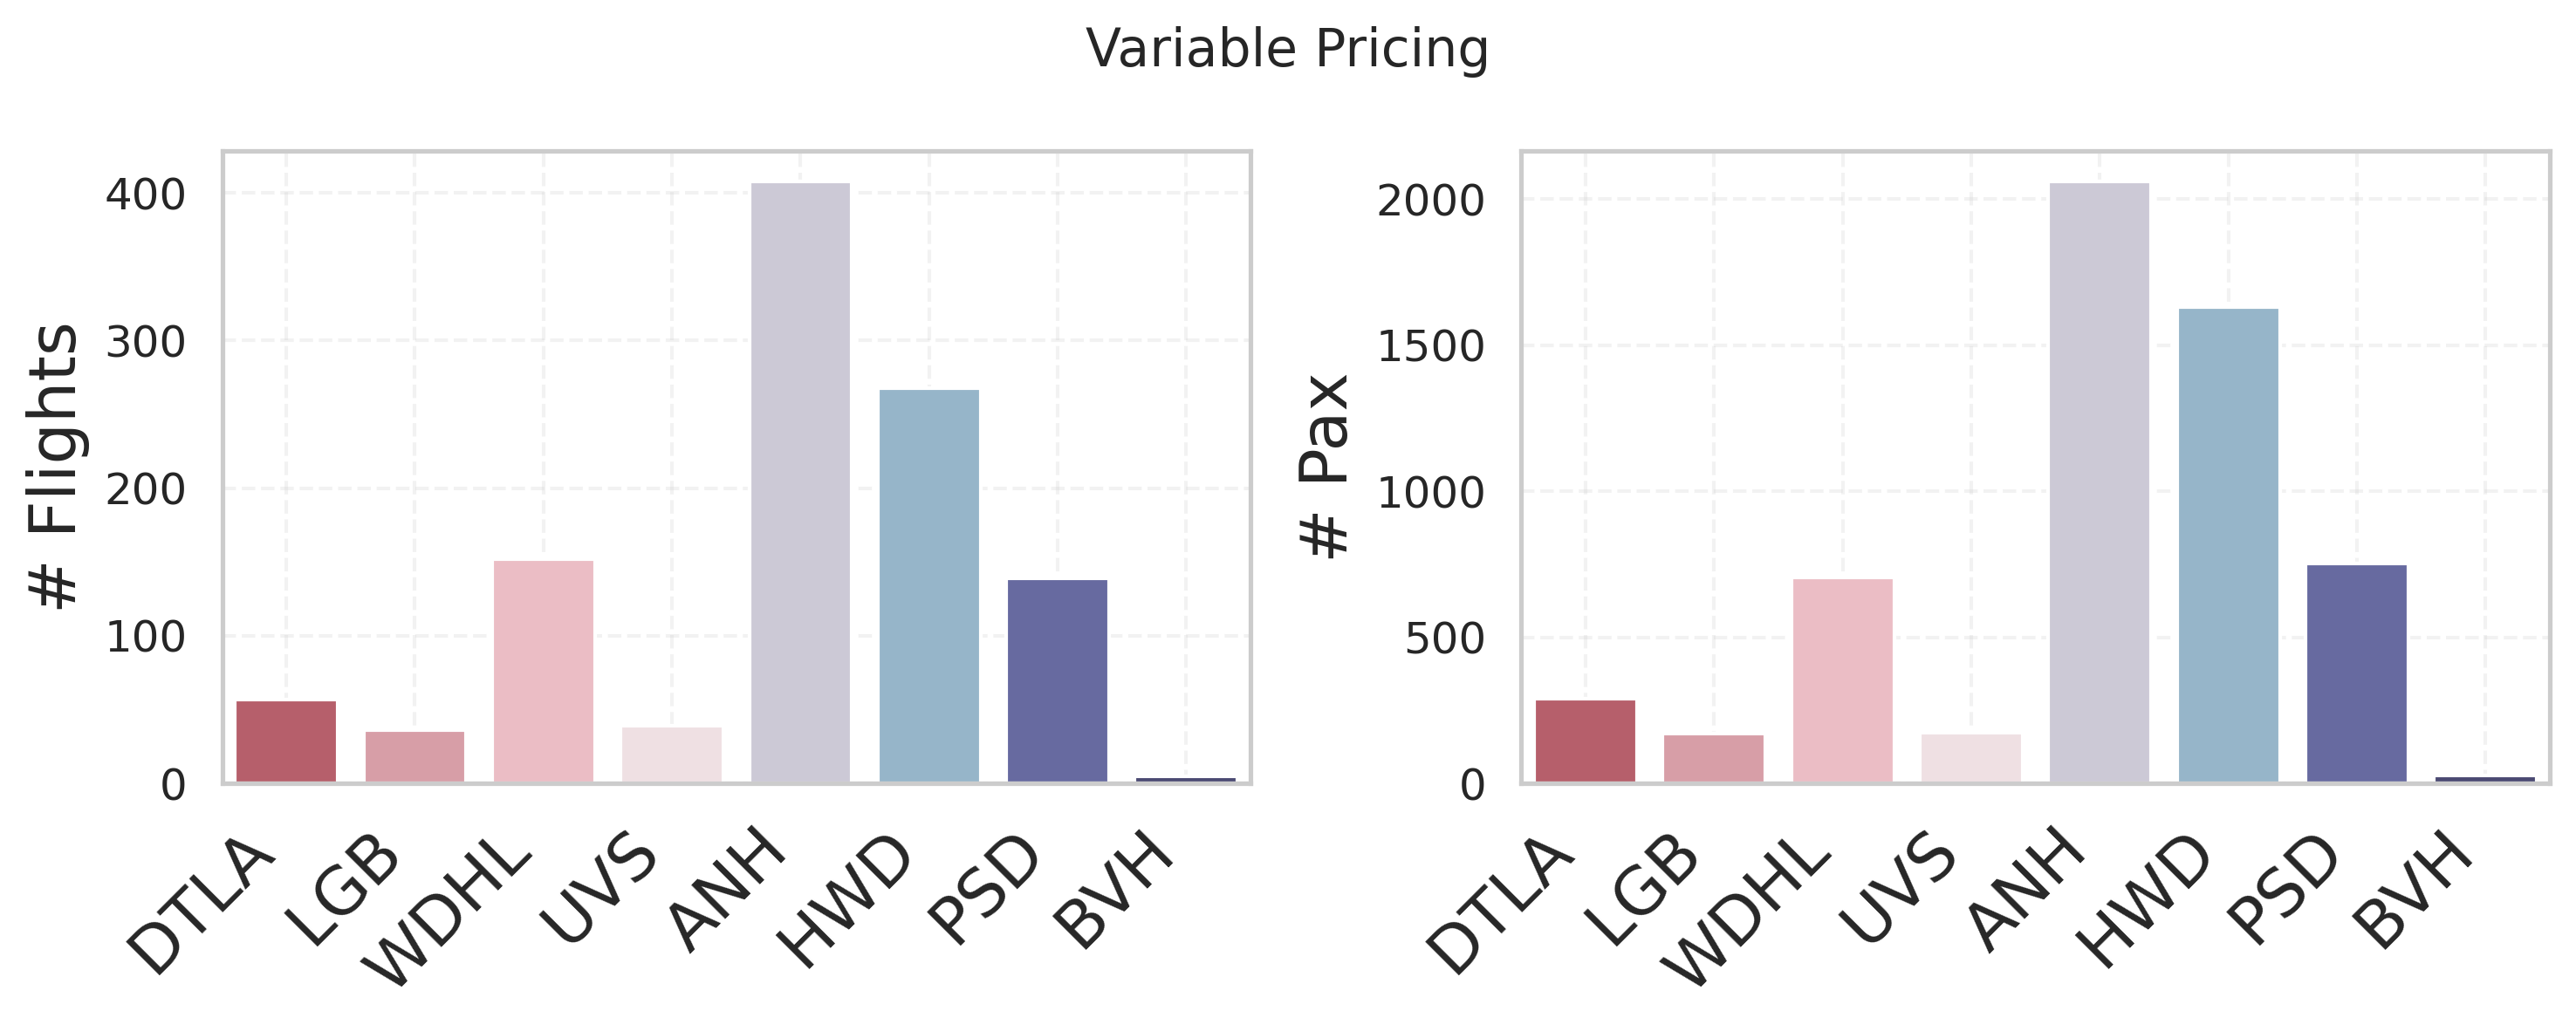

In [81]:
fig, ax = plt.subplots(figsize=(10, 4), dpi=300, ncols=2)
sns.barplot(data=joined, x='market', y='num_flight', ax=ax[0], palette=custom_colors)
sns.barplot(data=joined, x='market', y='num_pax', ax=ax[1], palette=custom_colors)
ax[0].set_ylabel("# Flights")
ax[1].set_ylabel("# Pax")
for i in range(2):
    ax[i].tick_params(axis='y', labelsize=12)
    ax[i].set_xlabel("")
    ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=45, ha='right')
    ax[i].grid(True, alpha=0.25, linestyle='--', which='both')
fig.suptitle("Variable Pricing")

plt.tight_layout()

In [79]:
path = 'output/ECO_WAIT10_FARE3_NOV27/'
path = 'output/pricing_output_scale_1/'
policy_0 = pd.read_csv(path + "25_4_4_4.csv")
summary_0 = FleetOpVRPSummary(network, policy_0)
statistics_0 = summary_0.get_summary_statistics()
df = pd.DataFrame([statistics_0])

RASM ......................... : $2.329
CASM ......................... : $0.997
  - ENERGY                   : $0.091
  - PILOT                    : $0.215
  - BATTERY_REPLACEMENT      : $0.082
  - MAINTENANCE              : $0.190
  - INSURANCE                : $0.037
  - VERTIPORT_OPERATION      : $0.292
  - ADMINISTRATION           : $0.090


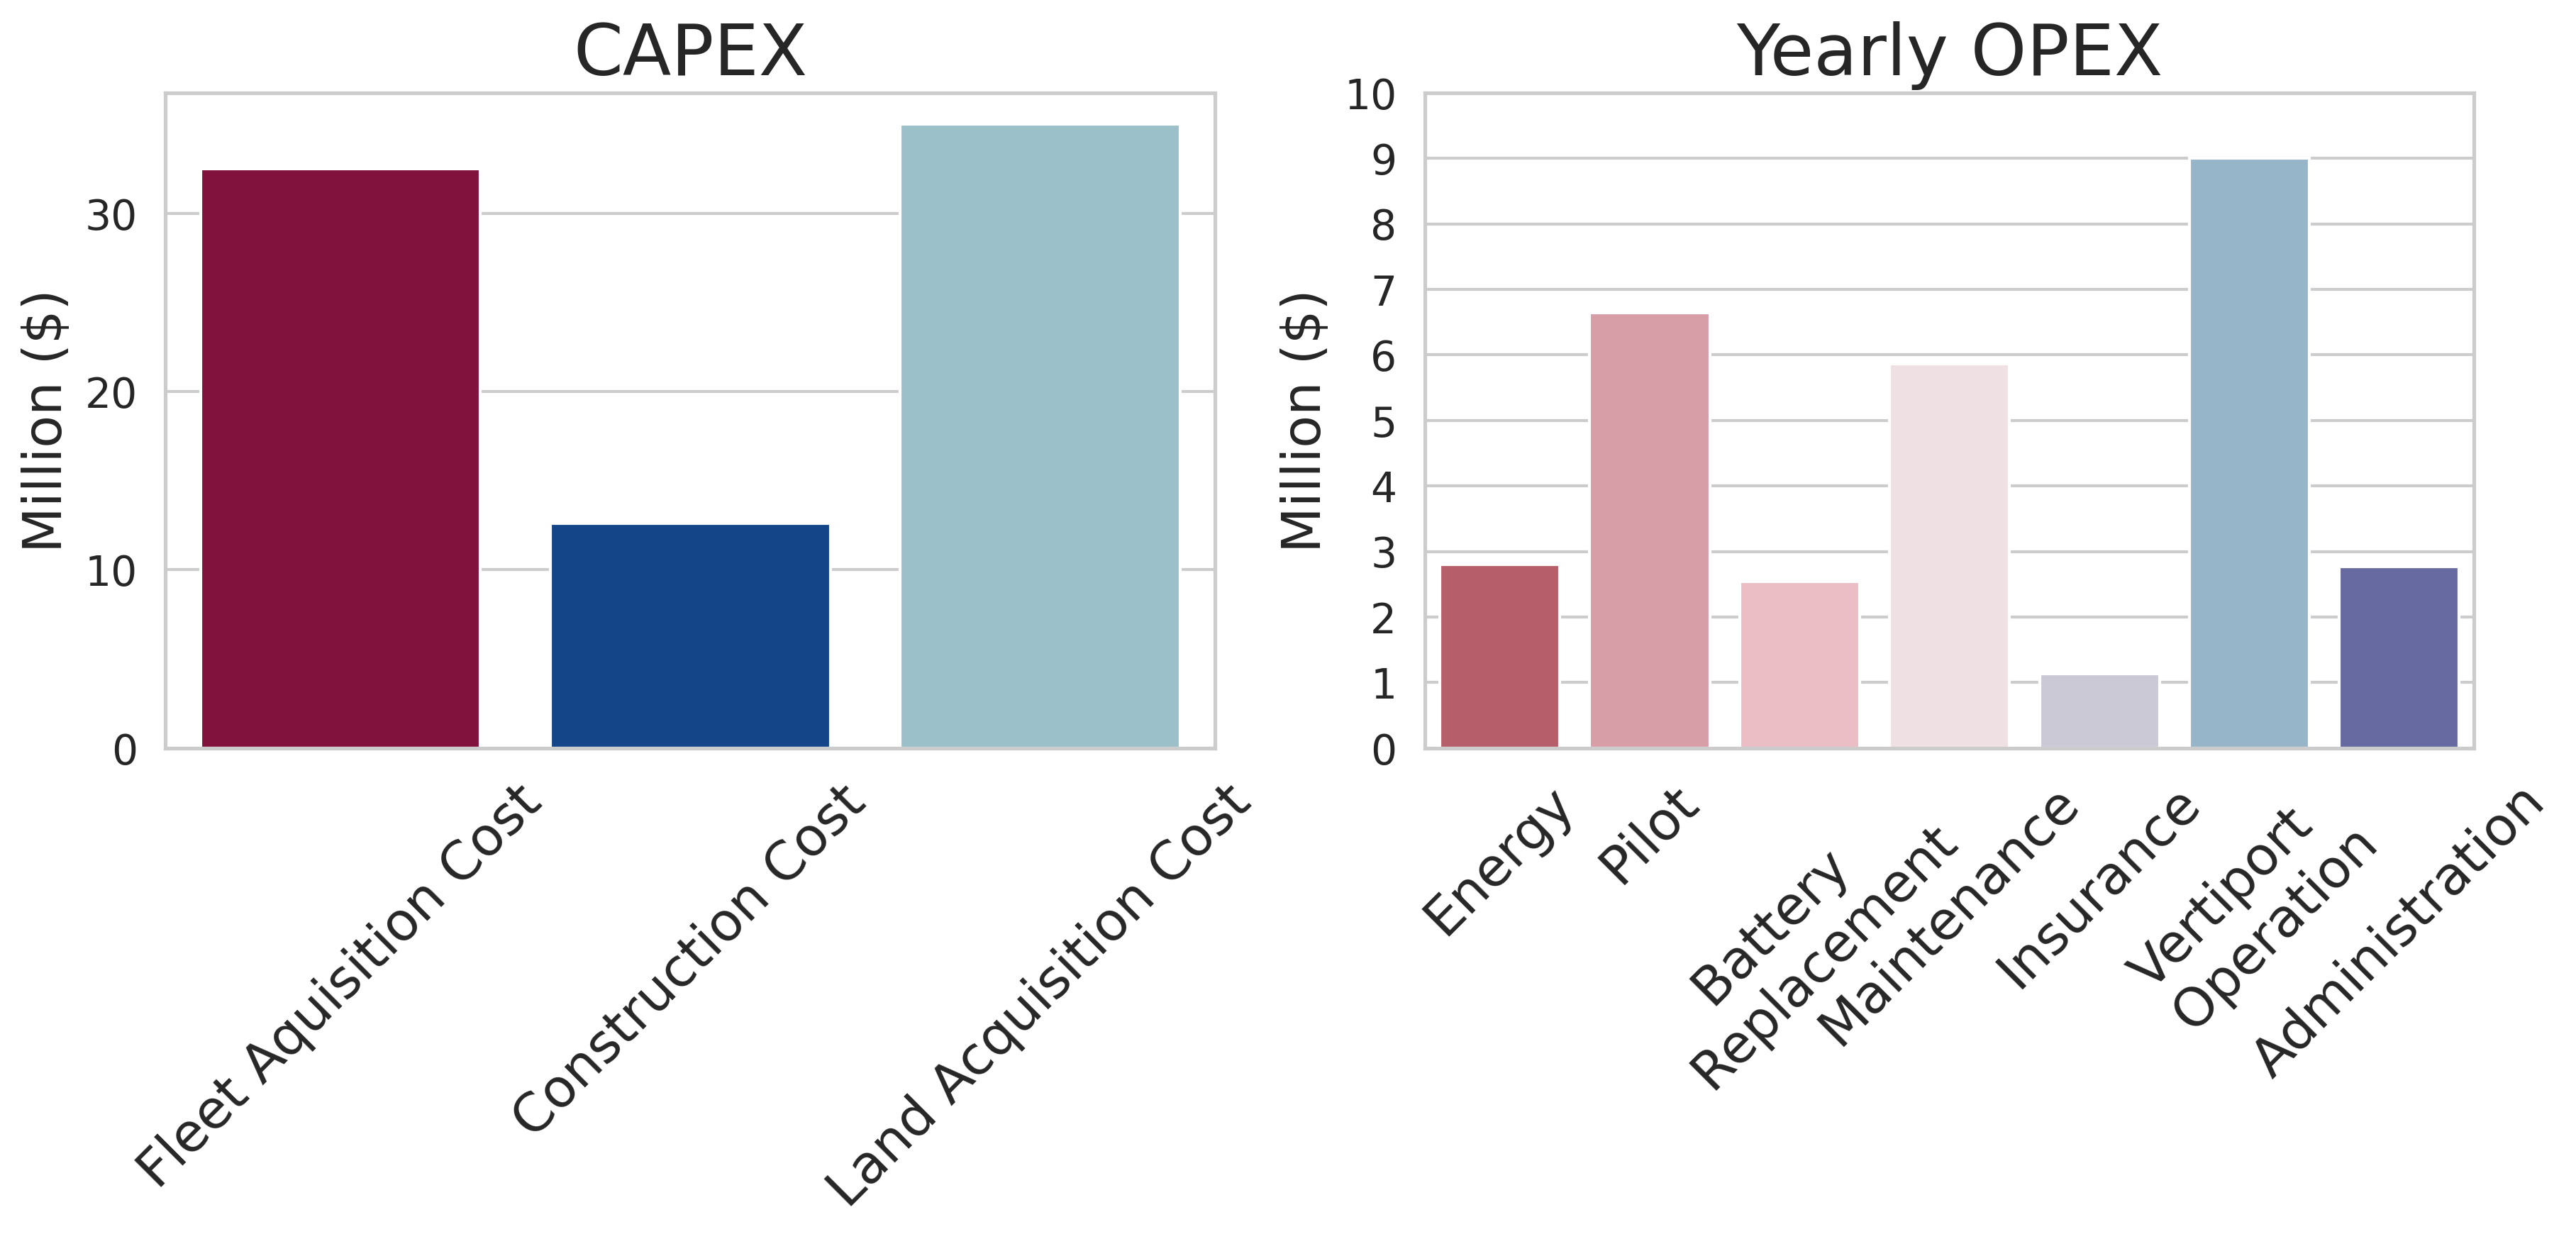

In [51]:
c = CostAnalyzer("../UAM-System-Model/uam_system_model/data/config/financial_analysis_params.json")
capex, opex, rev, prof = c.analyze(df)
c.plot();

In [54]:
print("CAPEX: ", capex, "DAILY REVENUE: ", round(rev/365,2), "DAILY OPEX: ", round(opex/365,2), " Profit: ", prof)

CAPEX:  80115680.06 DAILY REVENUE:  196828.46 DAILY OPEX:  84266.7  Profit:  41085042.93


ROI (undiscounted) ............ : 3.39
NPV @ 8% ............. : $271,550,869
IRR ........................... : 51.18%
Discounted Payback ............ : 3 years


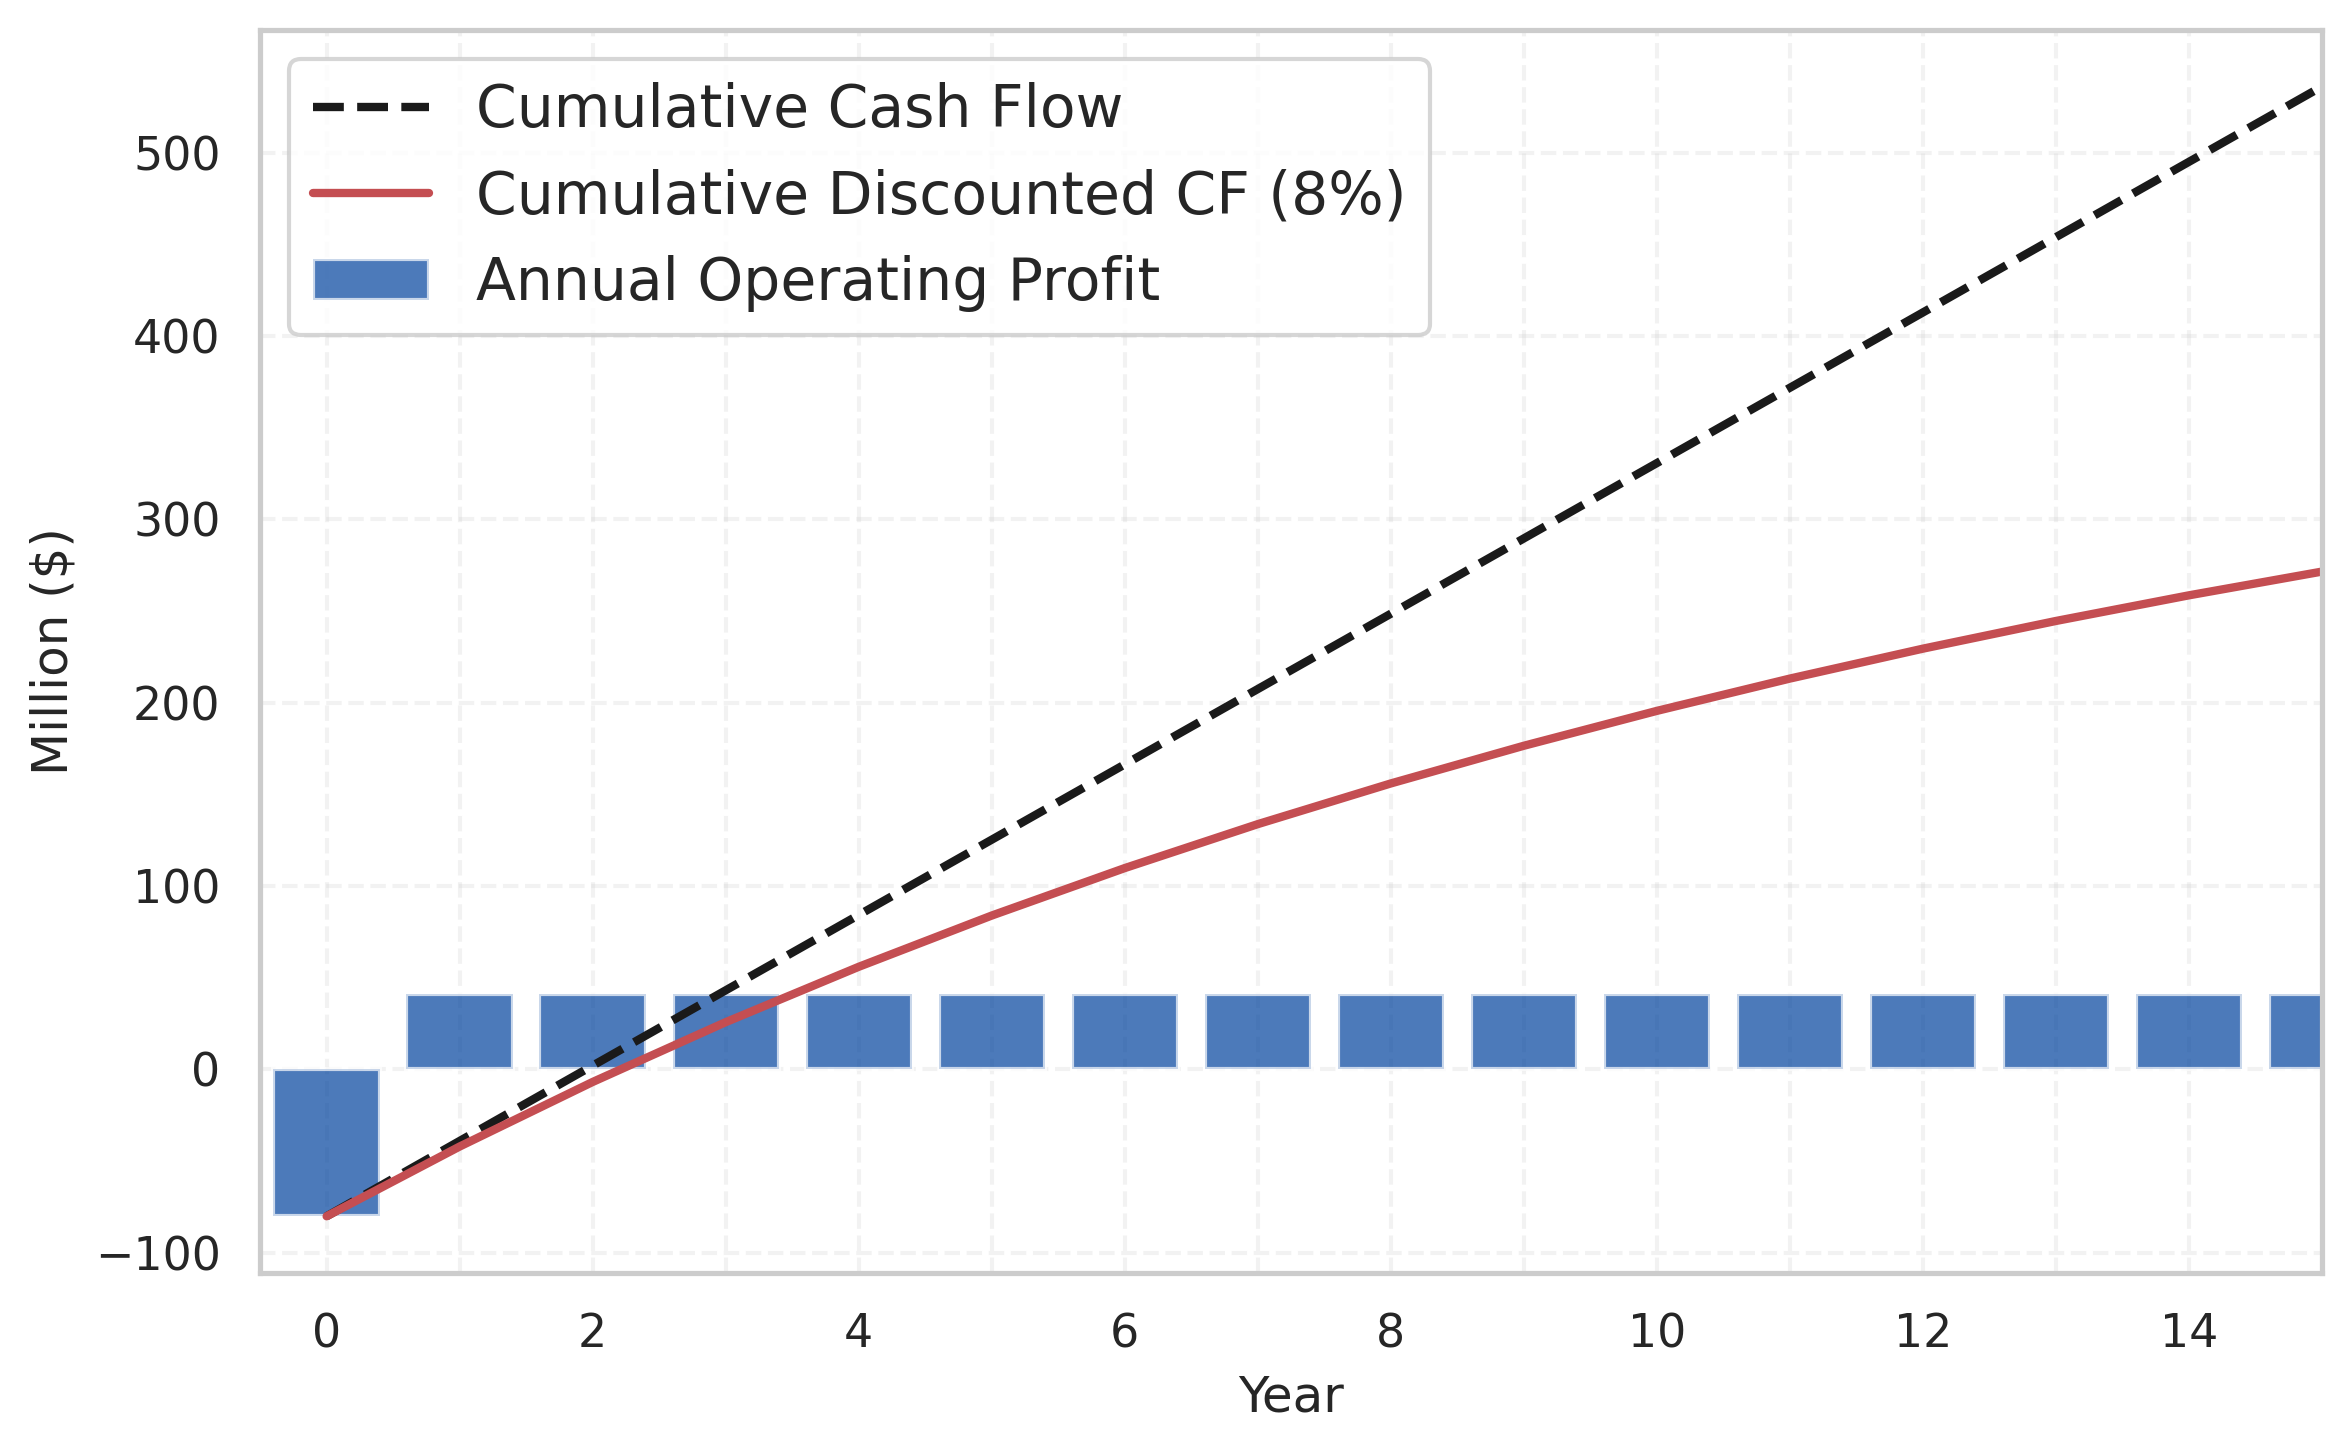

In [56]:
fig, ax, ROI, NPV, IRR, payback_year = c.projection()